# Churn Analysis and Customer Intelligence

In [5]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

# 1. Import database / data

In [6]:
# # Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
            SELECT name
            FROM sqlite_master
            WHERE type='table'
            """

# read sql query in pandas
tables = pd.read_sql(sql_query,conn)

#              name
# 0     db_customer
# 1  db_subscription
# 2      db_support

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}",conn)
    globals()[f"df_{table_name}"]=df
    print(f"Created DataFrame :df_{table_name}")


# Close connection
conn.close()
    

Created DataFrame :df_db_customer
Created DataFrame :df_db_subscription
Created DataFrame :df_db_support


In [7]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# 2. Data cleaning

In [12]:
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [10]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,NaN,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,NaN,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [11]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name to customer_name
# b. drop columns - interest and pincode
# c. change data type - dob
# d. data standardization - gender
# e. fix missing values (using existing data) - country

# a. Rename Col

In [15]:
# a. rename col - name to customer_name
df_db_customer.rename(columns={'name':'customer_name'},inplace=True)

 # b. drop columns 

In [32]:
# b. drop columns - interest and pincode
#I. by index:
# df_db_customer.drop(df_db_customer.columns[6:], axis=1)
df_db_customer.drop(df_db_customer.columns[-2:],axis=1,inplace=True)


#II. by column name:
# df_db_customer.drop(columns=['interests','pincode'])

In [33]:
df_db_customer.columns[-2:]

Index(['gender', 'dob'], dtype='str')

# c. change data type - dob

In [25]:
# c. change data type - dob
df_db_customer['dob']=pd.to_datetime(df_db_customer['dob'])

# d. data standardization - gender

In [30]:
# d. data standardization - gender
df_db_customer['gender'].unique()


<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [29]:
df_db_customer['gender']=df_db_customer['gender'].replace({'Men':'Male','Women':'Female'})

# e. fix missing values (using existing data) - country

In [34]:
# e. fix missing values (using existing data) - country
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     str           
 1   customer_name  21 non-null     str           
 2   country        18 non-null     str           
 3   state          21 non-null     str           
 4   gender         21 non-null     str           
 5   dob            21 non-null     datetime64[us]
dtypes: datetime64[us](1), str(5)
memory usage: 1.1 KB


In [38]:

# df_db_customer['country'].isna().sum()
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [52]:
# country and state - unique value pair

# Creating state → country map from non-null rows
state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

# Fill the missing country using State
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [54]:

df_db_customer.isna().sum()

customerid       0
customer_name    0
country          0
state            0
gender           0
dob              0
dtype: int64

In [61]:
df_db_subscription.head(8)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88
5,0013-MHZWF,2022-06-18,Paid,2025-06-18,Standard,Annual,NaN,NaN,17.99,720,22
6,0013-SMEOE,2021-09-30,Refferal,2024-09-30,Basic,Monthly,2024-11-15,Not enough content,8.99,230,79
7,0014-BMAQU,2020-02-14,Organic,2025-02-14,Premium,Annual,NaN,NaN,22.99,1840,5


# subscription table

In [56]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [69]:
#a. change data type of dates str to datetime (subscription_start_date, renewal_date, cancellation_date )
date_col = ['subscription_start_date','renewal_date','cancellation_date']
df_db_subscription[date_col]=df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      datetime64[us]
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](3), float64(1), int64(2), str(5)
memory usage: 1.9 KB


#  support table

In [86]:
df_db_support.head() # support table

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30


In [71]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      str   
 1   complaint_date  9 non-null      str   
 2   escalations     9 non-null      str   
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      str   
dtypes: int64(1), object(1), str(4)
memory usage: 564.0+ bytes


In [78]:
df_db_support.drop(columns=['col_1','comment'], inplace = True)

In [79]:
df_db_support['complaint_date']=pd.to_datetime(df_db_support['complaint_date'])

In [80]:
df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


# 3. Feature Engineering & Data Analysis

In [81]:
df_db_subscription.head(3)

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34


Create a new col

In [83]:
# create a new col using existing col - churn flag (why? - For Calculating Churn Rate)

# Customer is churned if cancellation_date is not null

df_db_subscription['churn_flag']=np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [85]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


# Merge Dataframes - JOINs

In [91]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))


In [94]:
df_db_subscription.shape

(21, 12)

In [95]:
df.shape

(23, 20)

In [96]:
print('df_db_subscription unique value:', df_db_subscription['customerid'].nunique())
print('df_db_customer unique value:', df_db_customer['customerid'].nunique())
print('df_db_support unique value:', df_db_support['customerid'].nunique())
print('df_db_support all value:', df_db_support['customerid'].size)

df_db_subscription unique value: 21
df_db_customer unique value: 21
df_db_support unique value: 7
df_db_support all value: 9


In [118]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [105]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [117]:
df_db_support

,customerid,complaint_date,escalations,csat_score,complaint_count
2,0013-EXCHZ,2024-01-20,Y,20,1
5,0017-IUDMW,2024-04-10,Y,25,1
1,0003-MKNFE,2024-08-28,Y,10,2
8,0022-TCJCI,2024-09-14,N,90,2
6,0019-EFAEP,2024-09-27,Y,30,1
4,0013-SMEOE,2024-11-01,N,30,1
3,0013-MHZWF,2025-03-18,N,90,1


In [111]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [115]:
df=(df_db_subscription
    .merge(df_db_customer,on='customerid',how='left')
    .merge(df_db_support,on='customerid',how='left'))


In [116]:
df.shape

(21, 21)

# Export dataframe

In [121]:
df.to_csv('exported_churn_data.csv',index=False)

# Data Analysis

In [122]:
#1. Churn Rate

In [123]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [131]:
churn_rate=df['churn_flag'].mean()*100
print("Churn_Rate = ",round(churn_rate,2),"%")

Churn_Rate =  28.57 %


In [132]:
#2. Retention Rate

In [133]:
retention_rate=100 - churn_rate
print("Retention Rate = ",round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [135]:
#3. Churn By Plan type
df.

In [162]:
churn_by_plan=(df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

In [164]:
print(churn_by_plan)

  plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [170]:
# 4 a. Churn by state + sum(revenue) & count of users  
# 4 b. Churn by subscription type + sum(revenue) & count of users   
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [155]:
churn_by_state=(df.groupby('state')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))

In [156]:
print(churn_by_state)

           state  churn_rate_pct
0          Delhi           25.00
1      Karnataka          100.00
2      Kathmandu            0.00
3    Maharashtra            0.00
4      Meghalaya           66.67
5       Nagaland            0.00
6      Rajasthan            0.00
7      Telangana           50.00
8  Uttar Pradesh            0.00


In [168]:
churn_by_state=df.groupby('state').agg(
    churn_rate_pct=('churn_flag', lambda x: x.mean() * 100),
    user_count=('customerid', 'count'),
    revenue=('monthly_charges', 'sum')
).round(2)

In [169]:
print(churn_by_state)

               churn_rate_pct  user_count  revenue
state                                             
Delhi                   25.00           4    52.96
Karnataka              100.00           2    20.98
Kathmandu                0.00           2    20.98
Maharashtra              0.00           3    50.97
Meghalaya               66.67           3    42.97
Nagaland                 0.00           1    22.99
Rajasthan                0.00           2    36.98
Telangana               50.00           2    30.98
Uttar Pradesh            0.00           2   115.98


In [172]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [181]:
df.groupby('subscription_type').agg(
    churn_by_subscription_type=('churn_flag',lambda x: x.mean() * 100),
    users_count=('customerid','count'),
    revenue=('monthly_charges','sum')
).round(2)

,churn_by_subscription_type,users_count,revenue
subscription_type,,,
Organic,0.00,9,145.91
Paid,16.67,6,174.94
Refferal,83.33,6,74.94


In [186]:
# 5. ARPU - Avg Revenue per user (for check the quality of time)
arpu=df['monthly_charges'].mean()
print('ARPU=',arpu.round(2))

ARPU= 18.85


In [187]:
# homework - calculate customer age

In [210]:
 # 6. Avg Customer Tenure (how many days customer stay with us)
# count of days users has used our service : cancellation date else current date
# so subscription_start_date to cancellation_date(or till today)
today=pd.Timestamp.today()
# print(today)

df['tenure_days']= np.where(
    df['cancellation_date'].notna(),
    (df['cancellation_date']-df['subscription_start_date']).dt.days,
    (today-df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print("customer avg tenure =",round(avg_tenure) )

customer avg tenure = 1524


In [235]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk=df.loc[df['churn_flag']==1,'monthly_charges'].sum()
print("Revenue at Risk (Rs 'K') =", revenue_at_risk)

Revenue at Risk (Rs 'K') = 73.94


In [254]:
# 8. Esclation Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Esclation Rate = ", round(escalation_rate, 2), "%")

Esclation Rate =  19.05 %


In [258]:
# 9. Avg Complaint Per User
avg_complaints=df['complaint_count'].sum()/df['customerid'].nunique()
print("Avg Compliants Per User = ", round(avg_complaints, 2))

Avg Compliants Per User =  0.43


In [256]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days'],
      dtype='str')

In [269]:
# 10. Correlation Esclation vs Churn
df['escalations_flag'] = df['escalations'].map({ 'Y': 1,'N': 0})
corr_df=df[['escalations_flag','churn_flag']].dropna()

correlation = corr_df['escalations_flag'].corr(corr_df['churn_flag'])
print("Correlation Esclation vs Churn",correlation.round(2))

Correlation Esclation vs Churn 0.47


In [272]:
# 11. Create a column using existing col - Churn risk
conditions=[
    (df['churn_score']<50),
    (df['churn_score']>=50) & (df['churn_score']<70),
    (df['churn_score']>=70)
]

choices = ['low', 'med', 'high']

df['churn_risk']=np.select(conditions,choices,default='unkown')

# 4. Visualization using Matplotlib

In [277]:
# best practice to create a copy then work on it (back-up)
df_visual  = df.copy()

In [279]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalations_flag', 'churn_risk'],
      dtype='str')

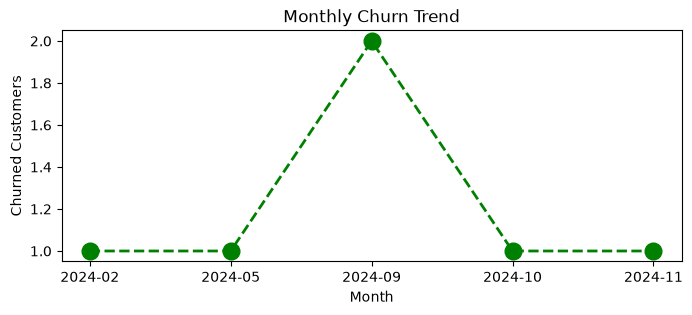

In [386]:
# 4.1 Monthly Churn Trend (Time Series KPI)
df_visual['cancellation_month']=df_visual['cancellation_date'].dt.to_period('M')

churn_trend=df_visual[df_visual['churn_flag']==1].groupby('cancellation_month').size()
plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str),churn_trend.values,color='green', marker='o', linestyle='--', linewidth=2, markersize=12)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')

plt.savefig('C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/churn_by_month.png',bbox_inches='tight')

plt.show()

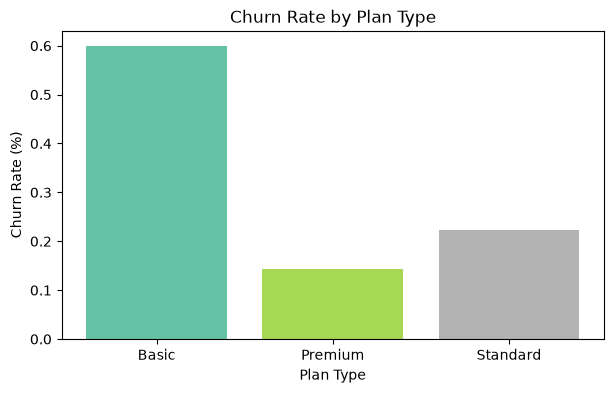

In [387]:
# 4.2 Churn Rate by Plan type
churn_plan=df_visual.groupby('plan_type')['churn_flag'].mean()
# colors = ['yellow', 'purple', 'blue'] - limit 
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))
plt.figure(figsize=(7,4))
plt.bar(churn_plan.index,churn_plan.values ,color=colors)
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate (%)')
plt.savefig('C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/churn_by_plan.png',bbox_inches='tight')
plt.show()

In [314]:
churn_plan.index

Index(['Basic', 'Premium', 'Standard'], dtype='str', name='plan_type')

In [315]:
churn_plan.values

array([0.6       , 0.14285714, 0.22222222])

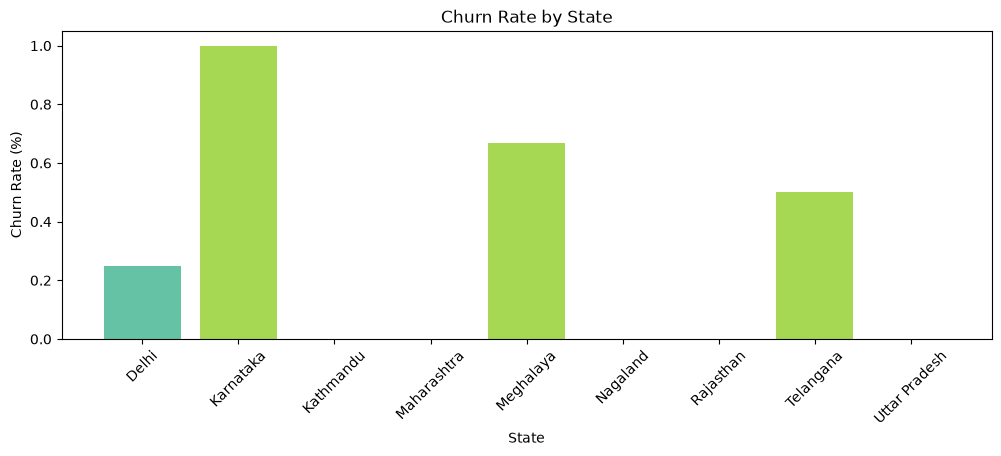

In [388]:
# 4.3 Churn by States

churn_state=df.groupby('state')['churn_flag'].mean()

# colors = ['yellow', 'purple', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))
plt.bar(churn_state.index, churn_state.values, color = colors)

plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=45)
plt.savefig('C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/churn_by_state.png',bbox_inches='tight')
plt.show()

# Visulaization using Seaborn

In [327]:
# Heatmap (Correlation Matrix)

In [329]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalations_flag', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [331]:
df_visual[[
    'monthly_charges',
    'cltv',
    'churn_score',
    'churn_flag',
    'csat_score',
    'complaint_count',
    'tenure_days'
]].head()



,monthly_charges,cltv,churn_score,churn_flag,csat_score,complaint_count,tenure_days
0,13.99,627,12,0,NaN,NaN,1988.0
1,12.99,1150,91,1,10.0,2.0,1501.0
2,6.99,210,34,0,NaN,NaN,1373.0
3,22.99,1725,8,0,NaN,NaN,2663.0
4,13.99,195,88,1,20.0,1.0,419.0


In [347]:
df_encoded.corr()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations_flag
plan_type,1.000000,0.623250,-0.454516,-0.361449,-0.308874,0.471405
contract_type,0.623250,1.000000,-0.636409,-0.517294,-0.540062,-0.091287
churn_score,-0.454516,-0.636409,1.000000,0.857224,0.926083,0.375487
churn_flag,-0.361449,-0.517294,0.857224,1.000000,0.946573,0.471405
churn_risk,-0.308874,-0.540062,0.926083,0.946573,1.000000,0.471405
escalations_flag,0.471405,-0.091287,0.375487,0.471405,0.471405,1.000000


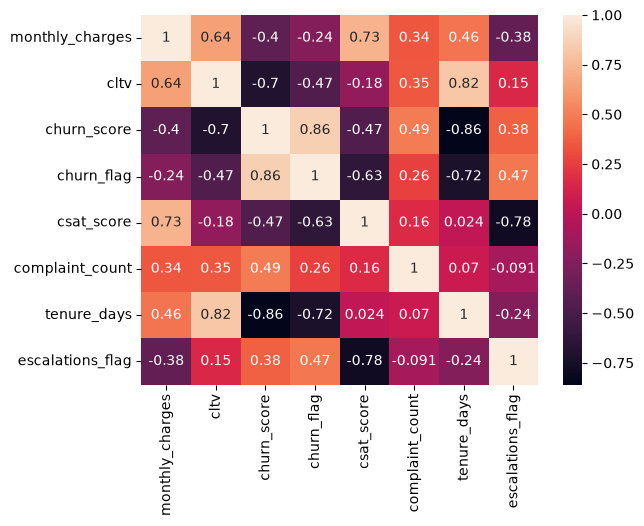

In [389]:
corr = df_visual[
    ['monthly_charges',
     'cltv',
     'churn_score',
     'churn_flag',
     'csat_score',
     'complaint_count',
     'tenure_days',
     'escalations_flag']
].corr()

sns.heatmap(corr, annot=True)
plt.savefig(
    'C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/correlation_heatmap.png',
    bbox_inches='tight'
)
plt.show()

In [340]:
print('plan_type :', df_visual['plan_type'].unique())
print('contract_type :', df_visual['contract_type'].unique())
print('churn_risk :', df_visual['churn_risk'].unique())

plan_type : <StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str
contract_type : <StringArray>
['Annual', 'Monthly']
Length: 2, dtype: str
churn_risk : <StringArray>
['low', 'high', 'med']
Length: 3, dtype: str


In [341]:
# Correct method of encoding - based on priority
df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations_flag']]

order_mappings = {
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk': ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes

In [344]:
df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,Y
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,Y


In [345]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations_flag
0,1,1,12,0,0,NaN
1,2,1,91,1,2,1.0
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,1.0


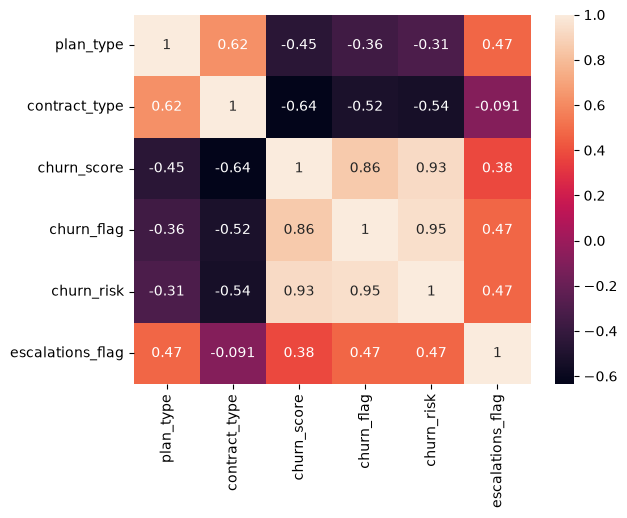

In [393]:
# Heatmap (correlation matrix)
sns.heatmap(df_encoded.corr(), annot=True)
plt.savefig(
    'C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/correlation_heatmap-encoding.png',
    bbox_inches='tight'
)

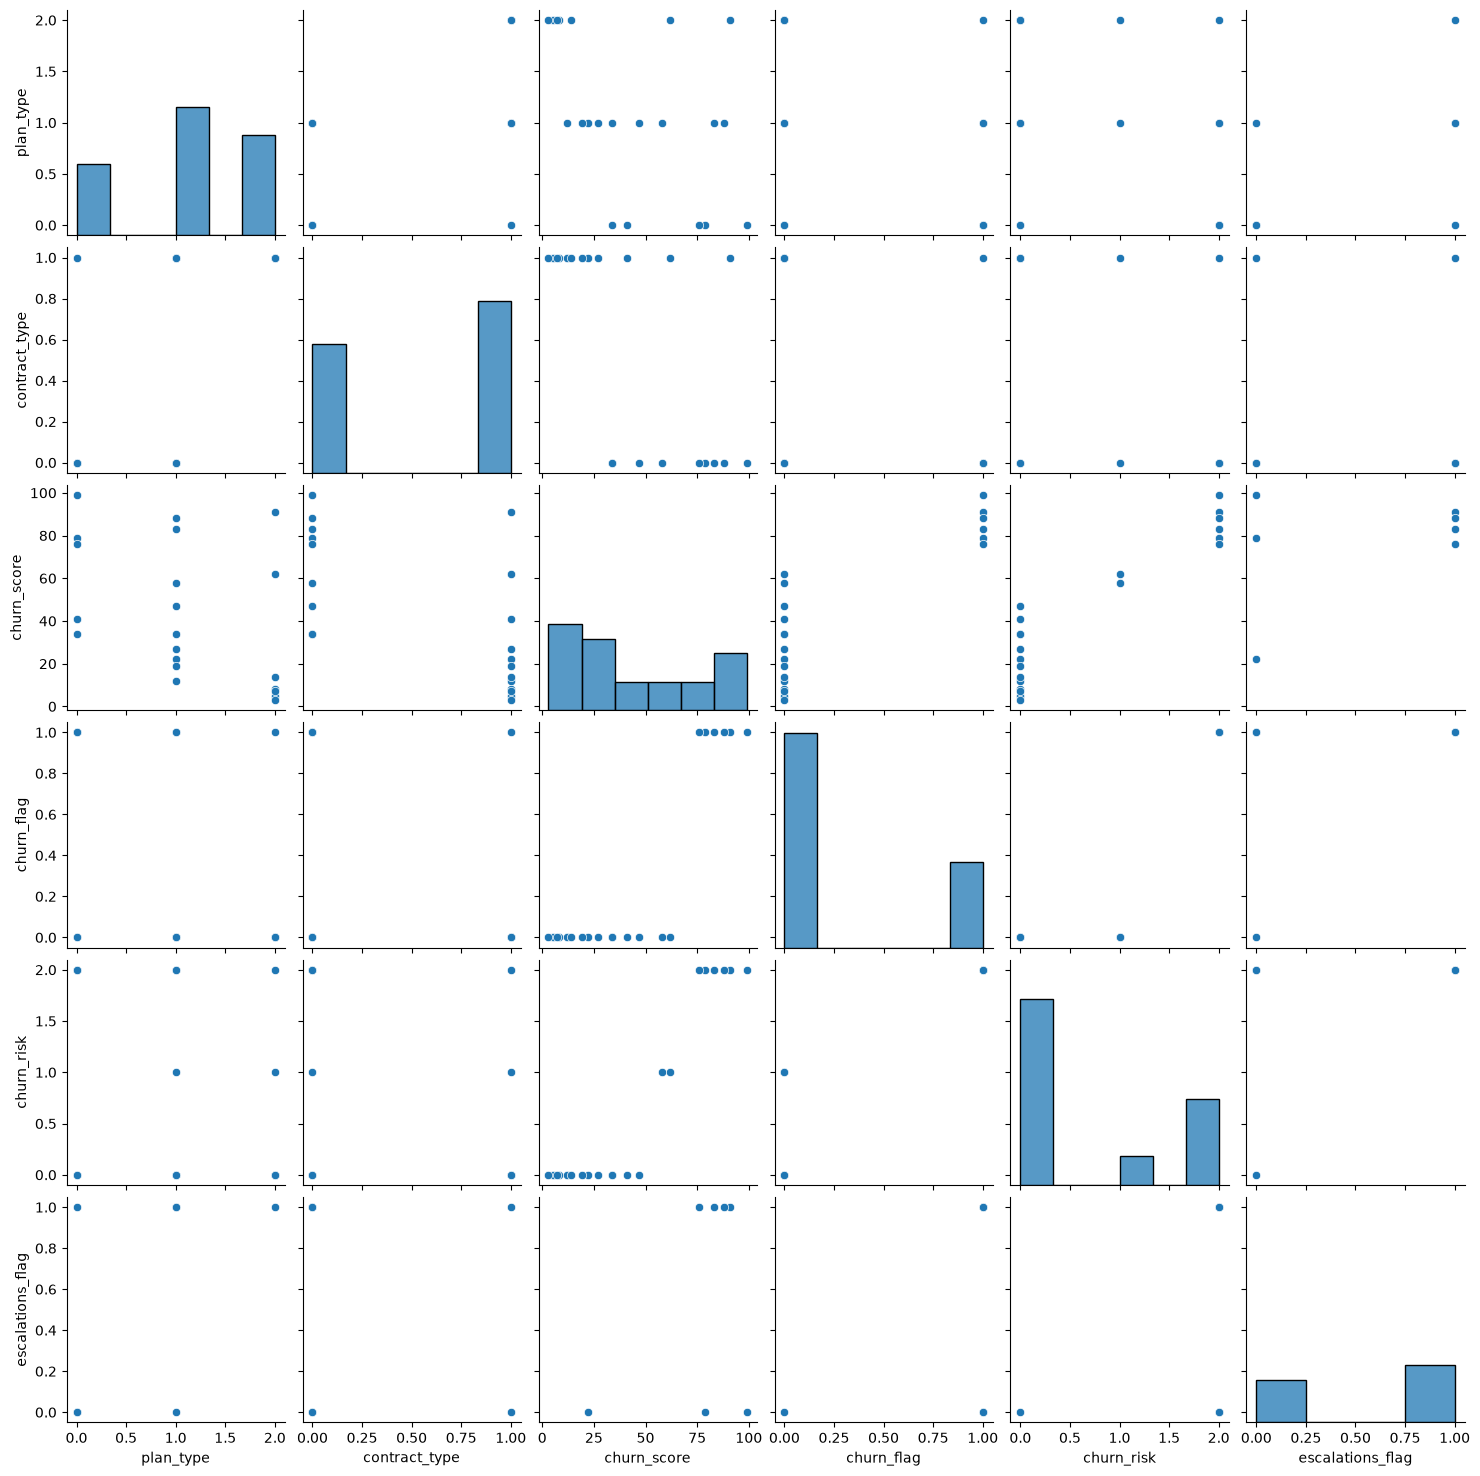

In [394]:
# pairplot - Plot pairwise relationships in a dataset
sns.pairplot(df_encoded)
plt.savefig(
    'C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/correlation-pairplot.png',
    bbox_inches='tight'
)

In [352]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'escalations_flag', 'churn_risk', 'cancellation_month'],
      dtype='str')

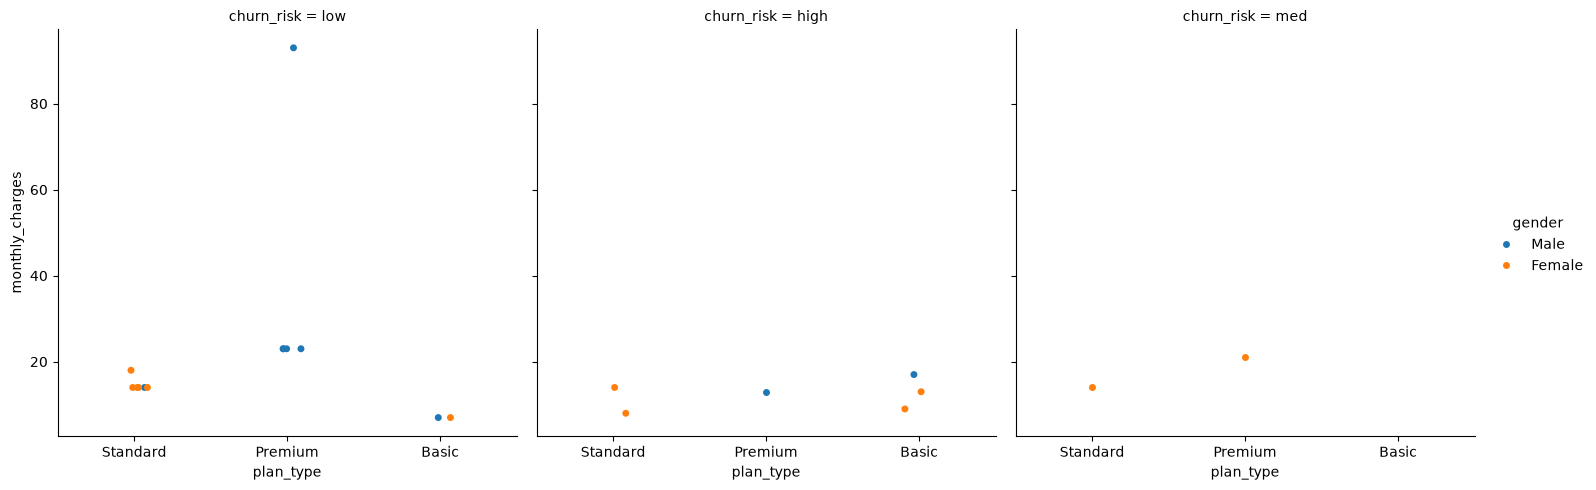

In [355]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

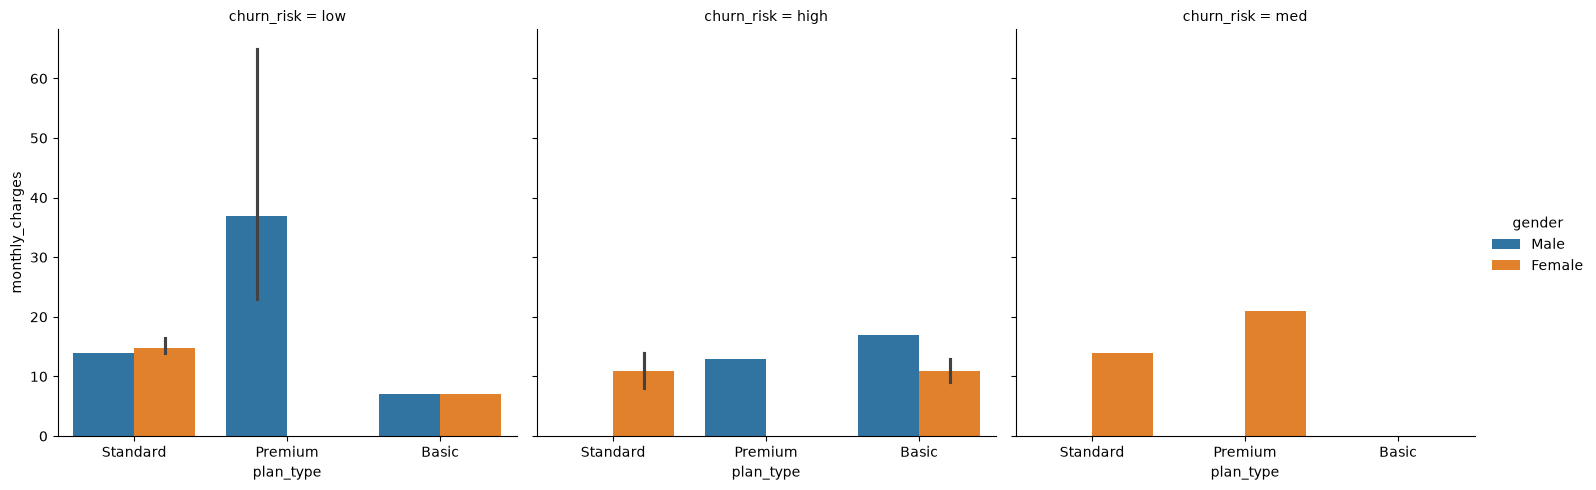

In [395]:
sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    kind='bar',
    col='churn_risk')

plt.savefig(
    'C:/Users/laksh/OneDrive/Desktop/coding/jbooks/Data Analysis Projects/customer-churn-analysis-and-customer-intelligence/Visuals/chatplot.png',
    bbox_inches='tight'
)

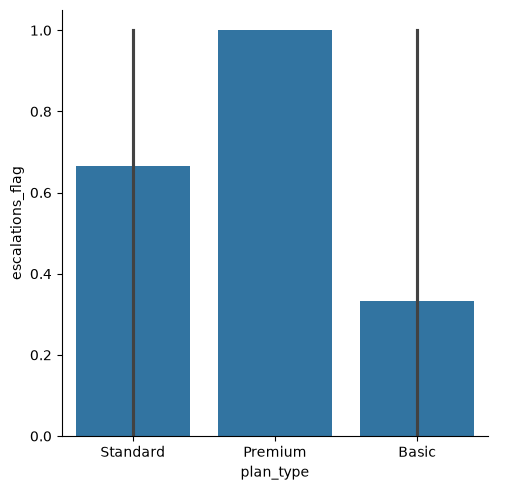

In [367]:
# chech count on plan type
sns.catplot(
    data=df_visual,
    x='plan_type',
    y='escalations_flag',
    kind='bar'
)

In [368]:
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values=['monthly_charges', 'churn_flag'],
    aggfunc=['mean', 'sum']
)

mean                        sum                
          churn_flag monthly_charges churn_flag monthly_charges
plan_type                                                      
Basic       0.600000       10.590000          3           52.95
Premium     0.142857       31.275714          1          218.93
Standard    0.222222       13.767778          2          123.91

# Pivot table

In [371]:
# Pivot Table

pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
)


,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [378]:
pivot_plan=pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
).reset_index()

In [379]:
print(pivot_plan)


  plan_type  churn_flag
0     Basic    0.600000
1   Premium    0.142857
2  Standard    0.222222


In [381]:
# pivot table using multiple cols and agg type
pd.pivot_table(
    data=df_visual,
    index='plan_type',
    values=['monthly_charges','customerid','churn_flag'],
    aggfunc={
            'monthly_charges': 'sum',
            'customerid':'nunique',
            'churn_flag':'mean'
    
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [382]:
pd.pivot_table(
    df_visual,
    index='plan_type',
    values='monthly_charges',
    aggfunc='sum'
)

,monthly_charges
plan_type,
Basic,52.95
Premium,218.93
Standard,123.91


In [383]:
#>>>>>>>>>>  completed